<a href="https://colab.research.google.com/github/osamamohamaed/Myprojects/blob/main/Bias_and_Fairness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Bias and Fairness in Machine Learning Models

## Objectives

By the end of this lab, students should be able to:

* Understand bias in datasets and models.
* Explore the impact of bias on model performance.
* Apply fairness metrics.
* Implement debiasing technique reweighing.

---

## Lab Overview

In this lab, you will build a classification pipeline on a hiring dataset and investigate whether the model behaves fairly across groups.

You will:

1. Load and inspect the dataset.
2. Identify the target and sensitive attribute.
3. Train a baseline classifier.
4. Measure performance metrics and fairness metrics.

**Sensitive attribute used :** `gender`
**Target variable:** `hired`


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score)

from fairlearn.metrics import (MetricFrame,selection_rate,demographic_parity_difference,equalized_odds_difference)


from aif360.algorithms.inprocessing import AdversarialDebiasing
import tensorflow.compat.v1 as tf
tf.disable_eager_execution()

from aif360.datasets import BinaryLabelDataset

In [ ]:
np.random.seed(10)

data = pd.DataFrame({

    "gender": np.random.choice([0, 1], 10000),
    "experience_years": np.random.randint(0, 25, 10000),

    "education_level": np.random.randint(1, 5, 10000),

    "interview_score": np.random.randint(50, 100, 10000),

    "skill_score": np.random.randint(50, 100, 10000),

    "previous_companies": np.random.randint(0, 6, 10000)})


acceptance_score = (
    data['experience_years'] * 0.4 +
    data['education_level'] * 0.3 +
    data['interview_score'] * 0.01 +
    data['skill_score'] * 0.01 +
    data['previous_companies'] * 0.01 +
    data['gender'] * 1.5 +
    np.random.randn(10000))

data['hired'] = (acceptance_score > 6).astype(int)

In [ ]:
print("\nHiring Distribution:")
print(data['hired'].value_counts())



print("\nBias by Gender:")
print(pd.crosstab(data['gender'], data['hired']))


Hiring Distribution:
hired
1    6764
0    3236
Name: count, dtype: int64

Bias by Gender:
hired      0     1
gender            
0       1945  3000
1       1291  3764


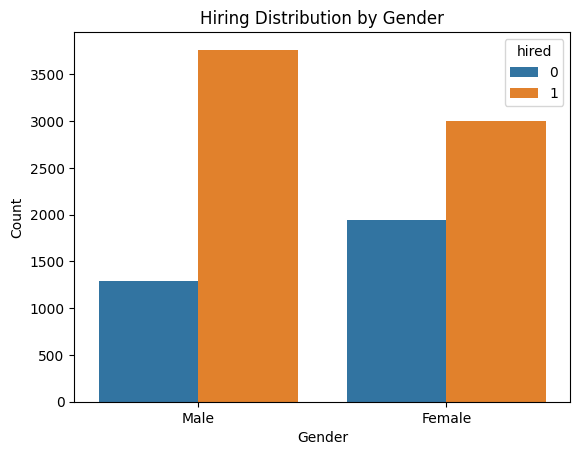

In [ ]:
plot = data.copy()
plot['gender'] = plot['gender'].map({0: 'Female',1: 'Male'})
sns.countplot( x='gender', hue='hired', data=plot)

plt.title("Hiring Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [ ]:
hiring_rate = data.groupby( 'gender')['hired'].mean()
print("\nHiring Rate:")
print(f"Female: {hiring_rate[0]:.2f}")
print(f"Male: {hiring_rate[1]:.2f}")


Hiring Rate:
Female: 0.61
Male: 0.74


# Step 2: Baseline Model

In [ ]:
X = data.drop(columns=["hired"])
y = data["hired"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5, stratify=y)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (8000, 6)
Testing shape: (2000, 6)


In [ ]:
Logistic_model = LogisticRegression()

Logistic_model.fit(X_train, y_train)

y_pred_log = Logistic_model.predict(X_test)

In [ ]:
print("Logistic Regression:")

print(f"Accuracy:{accuracy_score(y_test, y_pred_log):.4f}")

print(f"Precision:{precision_score(y_test, y_pred_log):.4f}")

print(f"Recall:{recall_score(y_test, y_pred_log):.4f}")

Logistic Regression:
Accuracy:0.9240
Precision:0.9451
Recall:0.9424


In [ ]:
mf = MetricFrame(
    metrics={ "accuracy": accuracy_score, "selection_rate": selection_rate},
    y_true=y_test,y_pred=y_pred_log,sensitive_features=X_test["gender"])

print("\nPerformance by Gender:")

print(mf.by_group)


Performance by Gender:
        accuracy  selection_rate
gender                          
0       0.928352        0.606960
1       0.919844        0.739003


In [ ]:
dp= demographic_parity_difference(y_test,y_pred_log,sensitive_features=X_test["gender"])

print("\ndemographic_parity_difference:")
print(round(dp, 3))



eo = equalized_odds_difference(y_test,y_pred_log,sensitive_features=X_test["gender"])

print("\nequalized_odds_difference:")
print(round(eo, 3))


demographic_parity_difference:
0.132

equalized_odds_difference:
0.043


# Step 3: Apply Preprocessing Technique – Reweighing



In [ ]:
train_df = X_train.copy()
train_df["hired"] = y_train.values

group_counts = train_df.groupby(['gender', 'hired']).size()
total = len(train_df)

weights = []
for i in range(len(train_df)):
    g = train_df.iloc[i]['gender']
    t = train_df.iloc[i]['hired']

    weight = total / group_counts[g][t]

    weights.append(weight)

sample_weights = np.array(weights)
print("First 10 Sample Weights:")
print(sample_weights[:10])

print("\nAverage Weight:")
print(sample_weights.mean())

First 10 Sample Weights:
[3.31537505 5.14469453 2.66844563 5.14469453 5.14469453 2.66844563
 3.31537505 3.31537505 3.31537505 3.31537505]

Average Weight:
3.999999999999999


In [ ]:
model_rw = LogisticRegression()

model_rw.fit(X_train,y_train,sample_weight=sample_weights[:len(X_train)])

y_pred_rw = model_rw.predict(X_test)

In [ ]:
print("\n Logistic Regression After Reweighing")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rw):.3f}")

print(f"Precision: {precision_score(y_test, y_pred_rw):.3f}")

print(f"Recall:    {recall_score(y_test, y_pred_rw):.3f}")


 Logistic Regression After Reweighing
Accuracy:  0.918
Precision: 0.965
Recall:    0.913


In [ ]:
mf_rw = MetricFrame(
    metrics={"accuracy": accuracy_score,"selection_rate": selection_rate},
    y_true=y_test,y_pred=y_pred_rw,sensitive_features=X_test["gender"])


print("\nPerformance by Gender After Reweighing:")
print(mf_rw.by_group)


Performance by Gender After Reweighing:
        accuracy  selection_rate
gender                          
0       0.930399        0.588536
1       0.907136        0.689150


In [ ]:
dp_rw = demographic_parity_difference(y_test,y_pred_rw,sensitive_features=X_test["gender"])

print("\nDemographic Parity Difference After Reweighing:")

print(round(dp_rw, 3))


eo_rw = equalized_odds_difference(y_test,y_pred_rw,sensitive_features=X_test["gender"])

print("\nEqual Opportunity Difference After Reweighing:")

print(round(eo_rw, 3))


Demographic Parity Difference After Reweighing:
0.101

Equal Opportunity Difference After Reweighing:
0.034


# Step 4: Apply In-Processing Technique – Adversarial Debiasing

In [ ]:
tf.reset_default_graph()

adv_data = data.copy()
dataset = BinaryLabelDataset(df=adv_data,label_names=['hired'],
protected_attribute_names=['gender'])

In [ ]:
train_dataset, test_dataset = dataset.split([0.8],shuffle=True)
sess = tf.Session()

In [ ]:
adv_model = AdversarialDebiasing(
    privileged_groups=[{'gender': 1}],
    unprivileged_groups=[{'gender': 0}],
    scope_name='adversarial_debiasing',
    debias=True,sess=sess)

In [ ]:
adv_model.fit(train_dataset)

epoch 0; iter: 0; batch classifier loss: 12.554070; batch adversarial loss: 0.693129
epoch 1; iter: 0; batch classifier loss: 1.221762; batch adversarial loss: 0.672919
epoch 2; iter: 0; batch classifier loss: 0.583894; batch adversarial loss: 0.699974
epoch 3; iter: 0; batch classifier loss: 0.496418; batch adversarial loss: 0.709698
epoch 4; iter: 0; batch classifier loss: 0.470386; batch adversarial loss: 0.681896
epoch 5; iter: 0; batch classifier loss: 0.654131; batch adversarial loss: 0.681171
epoch 6; iter: 0; batch classifier loss: 0.266341; batch adversarial loss: 0.683554
epoch 7; iter: 0; batch classifier loss: 0.334841; batch adversarial loss: 0.678520
epoch 8; iter: 0; batch classifier loss: 0.274957; batch adversarial loss: 0.688461
epoch 9; iter: 0; batch classifier loss: 0.274088; batch adversarial loss: 0.693024
epoch 10; iter: 0; batch classifier loss: 0.262013; batch adversarial loss: 0.687522
epoch 11; iter: 0; batch classifier loss: 0.268642; batch adversarial loss

In [ ]:
predictions = adv_model.predict(test_dataset)

In [ ]:
y_true_adv = test_dataset.labels.ravel()

y_pred_adv = predictions.labels.ravel()

In [ ]:
print("\n=== Adversarial Debiasing Model ===")

print(f"Accuracy:  {accuracy_score(y_true_adv, y_pred_adv):.4f}")

print(f"Precision: {precision_score(y_true_adv, y_pred_adv):.4f}")

print(f"Recall:    {recall_score(y_true_adv, y_pred_adv):.4f}")


=== Adversarial Debiasing Model ===
Accuracy:  0.9055
Precision: 0.9205
Recall:    0.9391


In [ ]:
sensitive_adv = test_dataset.protected_attributes.ravel()
mf_adv = MetricFrame(metrics={"accuracy": accuracy_score,"selection_rate": selection_rate},
    y_true=y_true_adv,
    y_pred=y_pred_adv,
    sensitive_features=sensitive_adv)

print("\nPerformance by Gender After Debiasing:")

print(mf_adv.by_group)


Performance by Gender After Debiasing:
                     accuracy  selection_rate
sensitive_feature_0                          
0.0                  0.902270        0.631787
1.0                  0.908815        0.727457


In [ ]:
dp_adv = demographic_parity_difference(y_true_adv,y_pred_adv,sensitive_features=sensitive_adv)

print("\ndemographic_parity_difference:")

print(round(dp_adv, 3))

eo_adv = equalized_odds_difference(y_true_adv, y_pred_adv, sensitive_features=sensitive_adv)

print("\nequalized_odds_difference:")

print(round(eo_adv, 3))


demographic_parity_difference:
0.096

equalized_odds_difference:
0.007


In [ ]:
comparison_df = pd.DataFrame({

    "Model": ["Baseline","Reweighing","Adversarial Debiasing"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rw),
        accuracy_score(y_true_adv, y_pred_adv)],

    "DP": [ dp, dp_rw, dp_adv],

    "EO": [ eo, eo_rw, eo_adv]})

print(comparison_df.round(3))

                   Model  Accuracy     DP     EO
0               Baseline     0.924  0.132  0.043
1             Reweighing     0.918  0.101  0.034
2  Adversarial Debiasing     0.906  0.096  0.007


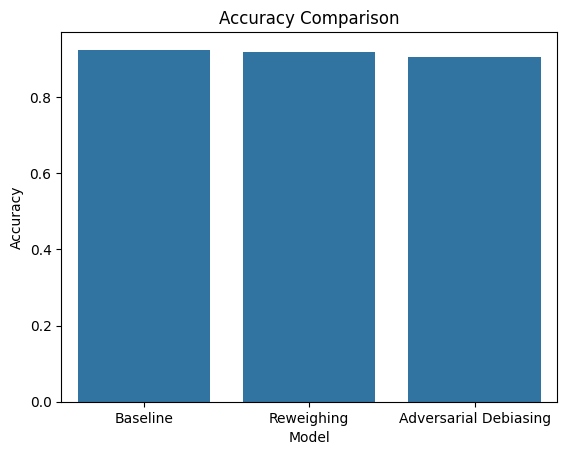

In [ ]:
sns.barplot(x="Model",y="Accuracy",data=comparison_df)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

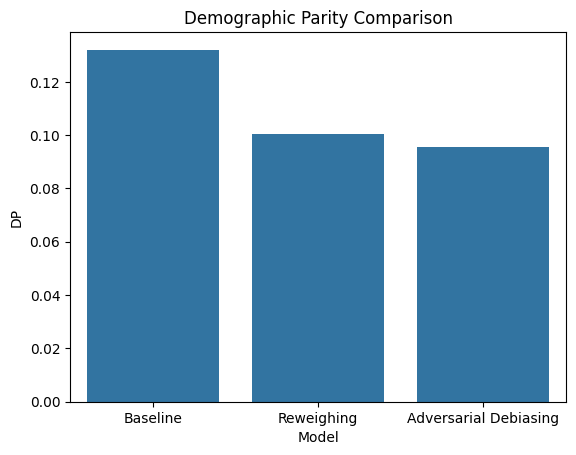

In [ ]:
sns.barplot(x="Model",y="DP",data=comparison_df)
plt.title("Demographic Parity Comparison")
plt.ylabel("DP")
plt.show()

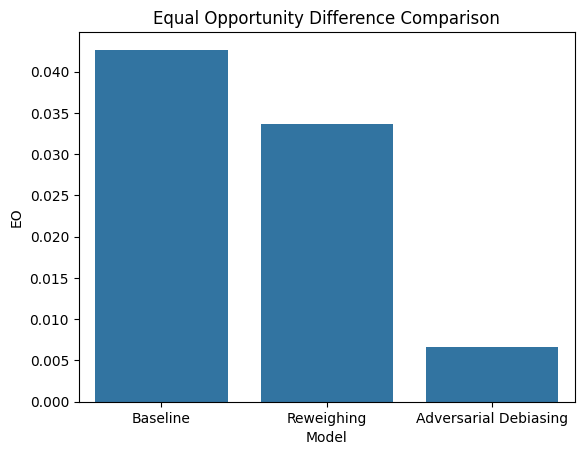

In [ ]:
sns.barplot(x="Model",y="EO",data=comparison_df)
plt.title("Equal Opportunity Difference Comparison")
plt.ylabel("EO")
plt.show()